In [123]:
import pandas as pd
import numpy as np
from matplotlib.pyplot import subplots
from ISLP import load_data
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression as LR
from ISLP.models import (summarize,
                         ModelSpec as MS)
from ISLP import confusion_table
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.naive_bayes import GaussianNB
import seaborn as sns
import matplotlib.pyplot as plt

# Question 13

## (a)

In [2]:
weekly = load_data('Weekly')
weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Year       1089 non-null   int64   
 1   Lag1       1089 non-null   float64 
 2   Lag2       1089 non-null   float64 
 3   Lag3       1089 non-null   float64 
 4   Lag4       1089 non-null   float64 
 5   Lag5       1089 non-null   float64 
 6   Volume     1089 non-null   float64 
 7   Today      1089 non-null   float64 
 8   Direction  1089 non-null   category
dtypes: category(1), float64(7), int64(1)
memory usage: 69.4 KB


In [3]:
weekly.tail()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
1084,2010,-0.861,0.043,-2.173,3.599,0.015,3.205160,2.969,Up
1085,2010,2.969,-0.861,0.043,-2.173,3.599,4.242568,1.281,Up
1086,2010,1.281,2.969,-0.861,0.043,-2.173,4.835082,0.283,Up
1087,2010,0.283,1.281,2.969,-0.861,0.043,4.454044,1.034,Up
1088,2010,1.034,0.283,1.281,2.969,-0.861,2.707105,0.069,Up


In [4]:
weekly.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


In [5]:
weekly.Direction.value_counts()

Direction
Up      605
Down    484
Name: count, dtype: int64

Text(0.5, 1.0, 'Volume')

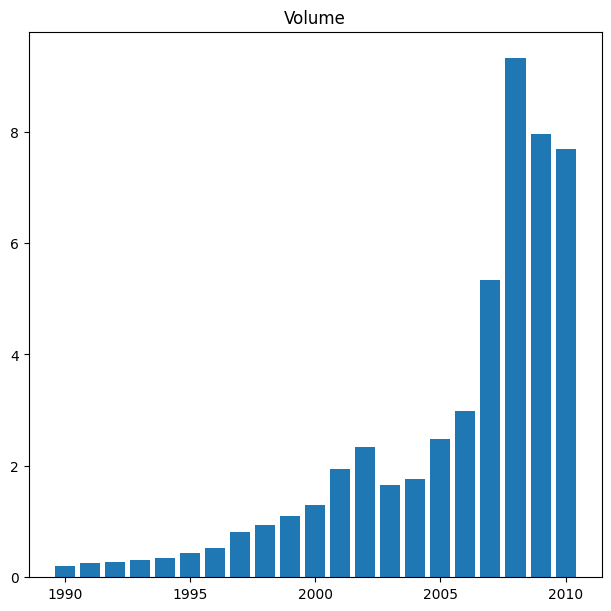

In [6]:
fig, ax = subplots(ncols=1, nrows=1, figsize=(6,6), layout='constrained')
x = weekly.Year
y = weekly.Volume
ax.bar(x, y)
ax.set_title('Volume')

In [7]:
weekly.describe()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


## (b)

In [171]:
X = MS(weekly.drop(columns=['Year', 'Today', 'Direction'])).fit_transform(weekly)
Y = weekly.Direction == 'Up'
Md_1 = sm.GLM(Y,
              X,
              family=sm.families.Binomial())
results = Md_1.fit()
summarize(results)


,coef,std err,z,P>|z|
intercept,0.2669,0.086,3.106,0.002
Lag1,-0.0413,0.026,-1.563,0.118
Lag2,0.0584,0.027,2.175,0.030
Lag3,-0.0161,0.027,-0.602,0.547
Lag4,-0.0278,0.026,-1.050,0.294
Lag5,-0.0145,0.026,-0.549,0.583
Volume,-0.0227,0.037,-0.616,0.538


lag2 appears to be more significant

## (c)

In [178]:
prob = results.predict()
labels = np.array(['Down']*1089, dtype=object)
labels[prob > 0.5] = 'Up'
c = confusion_table(labels, weekly.Direction)
c


Truth,Down,Up
Predicted,,
Down,54,48
Up,430,557


In [177]:
c.iloc[0,0]

np.int64(54)

In [10]:
np.mean(labels == weekly.Direction)

np.float64(0.5610651974288338)

the accuracy rate is 56% overall but in 430 cases it predicted up when market was down

## (d)

In [11]:
(weekly.Year > 2008).sum()


np.int64(104)

In [12]:
X = weekly['Lag2'].to_frame()
Y = weekly.Direction
x_train, x_test, y_train, y_test = train_test_split(X,
                                                    Y,
                                                    test_size=104,
                                                    shuffle=False)


In [13]:
Model_1 = LogisticRegression()


In [14]:
results_1 = Model_1.fit(x_train, y_train)
pred_1 = results_1.predict(x_test)
confusion_matrix(y_test, pred_1)

array([[ 9, 34],
       [ 5, 56]])

In [19]:
np.mean(pred_1 == y_test)


np.float64(0.625)

## (e)

since we will be using same method for rest of the problems, lets create a function with which we can calcualte the confuison matrix and accuracy easily

In [66]:
def fit_model(model):
    result = model.fit(x_train, y_train)
    pred = result.predict(x_test)
    print(confusion_table(pred, y_test))
    print(f'The accuracy for this model is {(np.mean(pred == y_test)):.3f}')  

In [55]:
model_2 = LDA(store_covariance=True)
fit_model(model_2)

Truth      Down  Up
Predicted          
Down          9   5
Up           34  56
The accuracy for this model is 0.625



## (f)

In [57]:
model_3 = QDA(store_covariance=True)
fit_model(model_3)

Truth      Down  Up
Predicted          
Down          0   0
Up           43  61
The accuracy for this model is 0.587


## (g)

In [58]:
model_4 = KNN(n_neighbors=1)
fit_model(model_4)

Truth      Down  Up
Predicted          
Down         22  31
Up           21  30
The accuracy for this model is 0.500


## (h)

In [59]:
model_5 = GaussianNB()
fit_model(model_5)

Truth      Down  Up
Predicted          
Down          0   0
Up           43  61
The accuracy for this model is 0.587


## (i)

From all these tests logistic regression and LDA gave an accuracy of 62.5% which is greater than null classifier, rest didn't performed as expected

## (j)

In [64]:
# lets try to find the accuracy  for diff values of k at first 
for k in range (1, 30):
    model = KNN(n_neighbors=k)
    print(f'\nk value :{k}')
    fit_model(model)


k value :1
Truth      Down  Up
Predicted          
Down         22  31
Up           21  30
The accuracy for this model is 0.500

k value :2
Truth      Down  Up
Predicted          
Down         31  43
Up           12  18
The accuracy for this model is 0.471

k value :3
Truth      Down  Up
Predicted          
Down         16  20
Up           27  41
The accuracy for this model is 0.548

k value :4
Truth      Down  Up
Predicted          
Down         26  27
Up           17  34
The accuracy for this model is 0.577

k value :5
Truth      Down  Up
Predicted          
Down         16  21
Up           27  40
The accuracy for this model is 0.538

k value :6
Truth      Down  Up
Predicted          
Down         20  28
Up           23  33
The accuracy for this model is 0.510

k value :7
Truth      Down  Up
Predicted          
Down         16  20
Up           27  41
The accuracy for this model is 0.548

k value :8
Truth      Down  Up
Predicted          
Down         21  24
Up           22  37
The a

we get maximum accuracy when k value was 20, i.e. around 59.6% which is quite impressive but not upto logistic and lda ones

In [45]:
39/(39+20)

0.6610169491525424

this is the accuracy for up, if we donot invest when it predicted down and only invest when it says up, then we would have correctly predicted 66.7% times which means almost 2/3rd of our bets will be correct.

now lets analyze by changing the parameters or considering other lag days too

In [92]:
def train_test_accuracy(req_predictors):
    y_response = weekly.Direction
    x_predictors = req_predictors
    x_train1, x_test1, y_train1, y_test1 = train_test_split(x_predictors,
                                                    y_response,
                                                    test_size=104,
                                                    shuffle=False)
    def fit_model1(method):
        if method == KNN:
            model = method(n_neighbors=1)
        else:
            model = method()
        result = model.fit(x_train1, y_train1)
        pred1 = result.predict(x_test1)
        print(f'{method.__name__}')
        print(confusion_table(pred1, y_test1))
        print(f'The accuracy is {(np.mean(pred1 == y_test1)):.3f}\n')
    models = [LR, LDA, QDA, GaussianNB, KNN]
    for m in models:
        fit_model1(m)
    
    

In [93]:
x3 = weekly[['Lag1', 'Lag2', 'Lag3']]
train_test_accuracy(x3)

LogisticRegression
Truth      Down  Up
Predicted          
Down          8   9
Up           35  52
The accuracy is 0.577

LinearDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          8   9
Up           35  52
The accuracy is 0.577

QuadraticDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          6  10
Up           37  51
The accuracy is 0.548

GaussianNB
Truth      Down  Up
Predicted          
Down          5  10
Up           38  51
The accuracy is 0.538

KNeighborsClassifier
Truth      Down  Up
Predicted          
Down         19  29
Up           24  32
The accuracy is 0.490



In [94]:
x4 = weekly[['Lag2']]
train_test_accuracy(x4)

LogisticRegression
Truth      Down  Up
Predicted          
Down          9   5
Up           34  56
The accuracy is 0.625

LinearDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          9   5
Up           34  56
The accuracy is 0.625

QuadraticDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          0   0
Up           43  61
The accuracy is 0.587

GaussianNB
Truth      Down  Up
Predicted          
Down          0   0
Up           43  61
The accuracy is 0.587

KNeighborsClassifier
Truth      Down  Up
Predicted          
Down         22  31
Up           21  30
The accuracy is 0.500



In [95]:
x5 = weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5']]
train_test_accuracy(x5)

LogisticRegression
Truth      Down  Up
Predicted          
Down         10  14
Up           33  47
The accuracy is 0.548

LinearDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          9  13
Up           34  48
The accuracy is 0.548

QuadraticDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down         10  23
Up           33  38
The accuracy is 0.462

GaussianNB
Truth      Down  Up
Predicted          
Down         10  21
Up           33  40
The accuracy is 0.481

KNeighborsClassifier
Truth      Down  Up
Predicted          
Down         21  28
Up           22  33
The accuracy is 0.519



In [97]:
x5 = weekly[['Lag2', 'Lag5']]
train_test_accuracy(x5)

LogisticRegression
Truth      Down  Up
Predicted          
Down          7   5
Up           36  56
The accuracy is 0.606

LinearDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          6   5
Up           37  56
The accuracy is 0.596

QuadraticDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          3  11
Up           40  50
The accuracy is 0.510

GaussianNB
Truth      Down  Up
Predicted          
Down          3  14
Up           40  47
The accuracy is 0.481

KNeighborsClassifier
Truth      Down  Up
Predicted          
Down         15  20
Up           28  41
The accuracy is 0.538



In [98]:
x6 = weekly[['Lag4', 'Lag5']]
train_test_accuracy(x6)

LogisticRegression
Truth      Down  Up
Predicted          
Down          0   3
Up           43  58
The accuracy is 0.558

LinearDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          0   3
Up           43  58
The accuracy is 0.558

QuadraticDiscriminantAnalysis
Truth      Down  Up
Predicted          
Down          9  16
Up           34  45
The accuracy is 0.519

GaussianNB
Truth      Down  Up
Predicted          
Down          9  16
Up           34  45
The accuracy is 0.519

KNeighborsClassifier
Truth      Down  Up
Predicted          
Down         19  29
Up           24  32
The accuracy is 0.490



# Question 14

## (a)

In [118]:
Auto = load_data('Auto')
Auto.median()
mpg01 = (Auto[['mpg']] > Auto['mpg'].median()).astype(int)
Auto['mpg01'] = mpg01
Auto.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0


## (b)

In [119]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.836939
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg01,0.836939,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


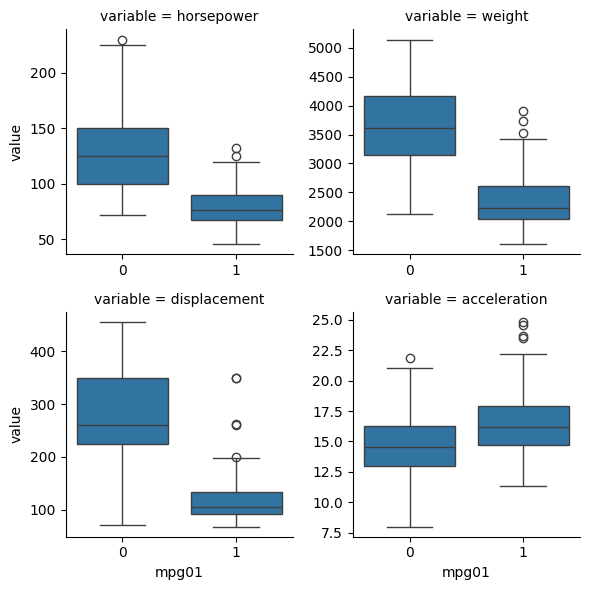

In [ ]:
cols = ["horsepower", "weight", "displacement", "acceleration"]

#melt helps to convert our data from multiple columns to the limited column with id and value
df_melt = Auto.melt(id_vars="mpg01", value_vars=cols)

#facetgrid helps to create four graphs, sharex,y help to keep scale diff from one another
g = sns.FacetGrid(df_melt, col="variable", col_wrap=2, sharex=False, sharey=False)
g.map_dataframe(sns.boxplot, x="mpg01", y="value")
plt.show()

from boxplot we can clearly see that mpg has strong association with horsepower, weight and displacement. using acceleration, it might be hard to classify as two boxes overlaps

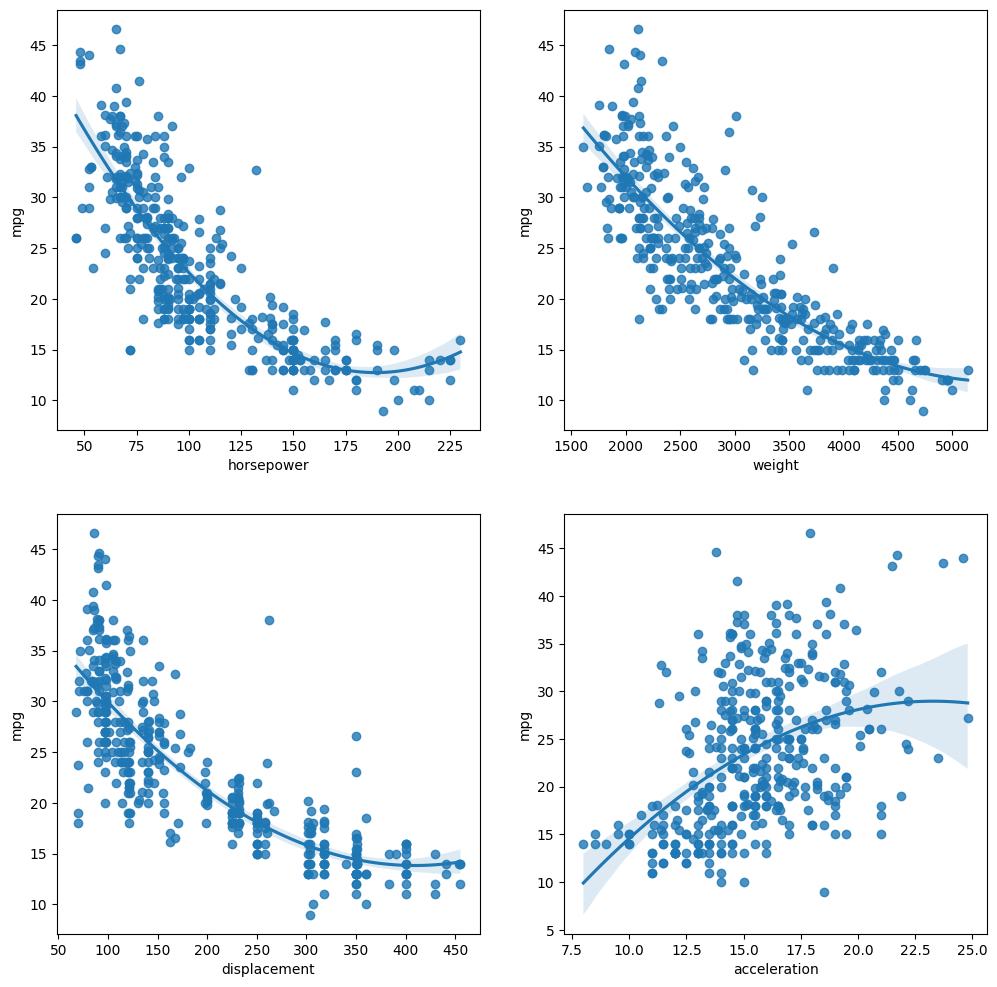

In [149]:
fig, ax = subplots(2,2, figsize=(12,12))
sns.regplot(data=Auto, x='horsepower', y='mpg', order=2, ax=ax[0,0])
sns.regplot(data=Auto, x='weight', y='mpg', order=2, ax=ax[0,1])
sns.regplot(data=Auto, x='displacement', y='mpg', order=2, ax=ax[1,0])
sns.regplot(data=Auto, x='acceleration', y='mpg', order=2, ax=ax[1,1])
plt.show()

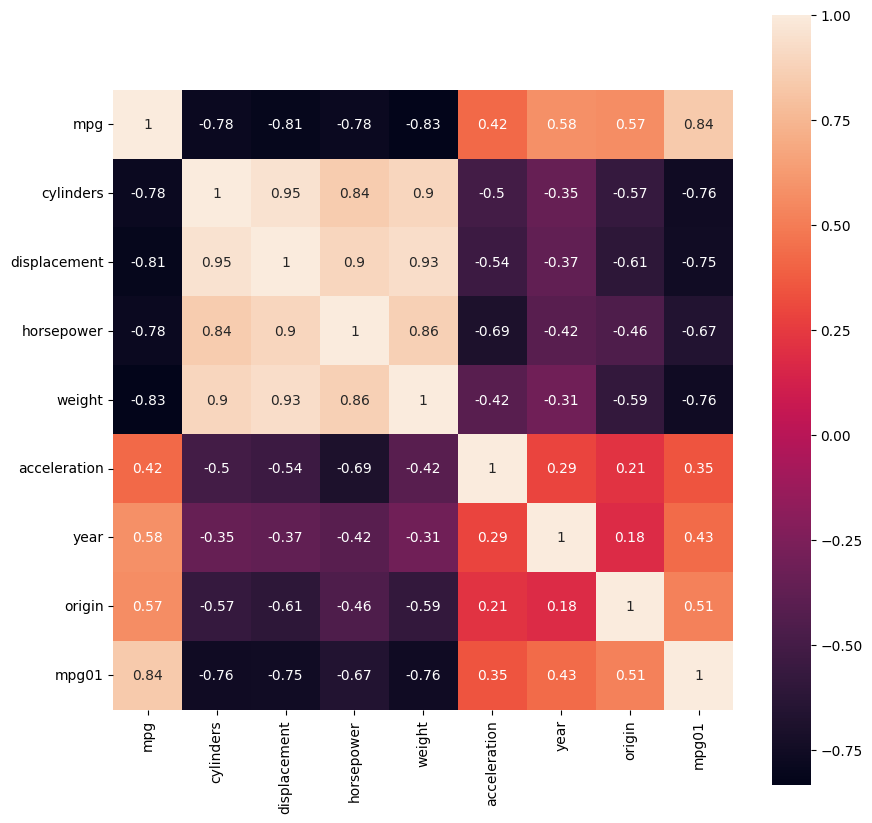

In [151]:
fig, ax = subplots(figsize=(10,10))
sns.heatmap(Auto.corr(), annot=True, square=True);
plt.show()

## (c)

In [192]:
x = Auto[['weight', 'horsepower', 'displacement', 'cylinders']]
y = Auto['mpg01']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)




from d-h we have to perform different analysis and check accuracy, so write one common function which will work for allmodels

In [199]:
def auto_dataset_analysis(global_model):
    g_model = global_model.fit(x_train, y_train)
    g_pred = g_model.predict(x_test)
    c = confusion_table(g_pred, y_test)
    error = 100*(c.iloc[1,0] + c.iloc[0,1]) / (c.sum().sum())
    print(c, f'\nThe error rate after {global_model} is {error:.3f}%\n')
    
    
    

## (d)

In [200]:
auto_lda = LDA()
auto_dataset_analysis(auto_lda)

Truth       0   1
Predicted        
0          58   3
1           7  50 
The error rate after LinearDiscriminantAnalysis() is 8.475%



## (e)

In [201]:
auto_qda = QDA()
auto_dataset_analysis(auto_qda)

Truth       0   1
Predicted        
0          61   5
1           4  48 
The error rate after QuadraticDiscriminantAnalysis() is 7.627%



## (f)

In [202]:
auto_lr = LR()
auto_dataset_analysis(auto_lr)

Truth       0   1
Predicted        
0          59   4
1           6  49 
The error rate after LogisticRegression() is 8.475%



## (g)

In [203]:
auto_nb = GaussianNB()
auto_dataset_analysis(auto_nb)

Truth       0   1
Predicted        
0          60   5
1           5  48 
The error rate after GaussianNB() is 8.475%



## (h)

In [208]:
#for knn analysis lets do standardization as it relies on the distance betn the values
scaler = StandardScaler(with_mean=True, with_std=True)
x_std = scaler.fit_transform(x)
x_std = pd.DataFrame(x_std, columns=x.columns)

In [209]:
x_train, x_test, y_train, y_test = train_test_split(x_std, y, test_size=0.3, random_state=1)

In [210]:
for k in range(1, 30):
    auto_k = KNN(n_neighbors=k)
    auto_dataset_analysis(auto_k)

Truth       0   1
Predicted        
0          57   6
1           8  47 
The error rate after KNeighborsClassifier(n_neighbors=1) is 11.864%

Truth       0   1
Predicted        
0          63   8
1           2  45 
The error rate after KNeighborsClassifier(n_neighbors=2) is 8.475%

Truth       0   1
Predicted        
0          59   6
1           6  47 
The error rate after KNeighborsClassifier(n_neighbors=3) is 10.169%

Truth       0   1
Predicted        
0          63   7
1           2  46 
The error rate after KNeighborsClassifier(n_neighbors=4) is 7.627%

Truth       0   1
Predicted        
0          60   5
1           5  48 
The error rate after KNeighborsClassifier() is 8.475%

Truth       0   1
Predicted        
0          61   6
1           4  47 
The error rate after KNeighborsClassifier(n_neighbors=6) is 8.475%

Truth       0   1
Predicted        
0          59   3
1           6  50 
The error rate after KNeighborsClassifier(n_neighbors=7) is 7.627%

Truth       0   1
Predic

the best value for k is 8 which resulted in error rate of 5.93%

# Question 15

## (a)

In [211]:
def power():
    ''' Prints out the result of raising 2 to the 3rd power'''
    print(2**3)

In [212]:
power()

8


## (b)

In [219]:
def power2(x, a):
    '''prints out the value of x**a'''
    print(x**a)

In [220]:
power2(3, 8)

6561


## (c)

In [222]:
power2(10,3), power2(8,17), power2(131,3);

1000
2251799813685248
2248091


## (d)

In [223]:
def power3(x, a):
    '''returns the result x**a'''
    result = x**a
    return result

## (e)

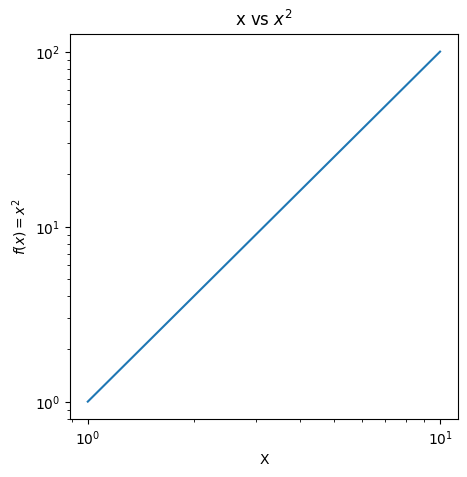

In [230]:
fig, ax = subplots(figsize=(5,5))
x = np.arange(1,11)
y = power3(x,2)
ax.plot(x,y)
ax.set_xlabel('X')
ax.set_ylabel('$f(x) = x^2$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('x vs $x^2$')
plt.show()


## (f)

In [231]:
def PlotPower(seq, pow):
    x = seq
    y = x**pow
    plt.plot(x,y)
    

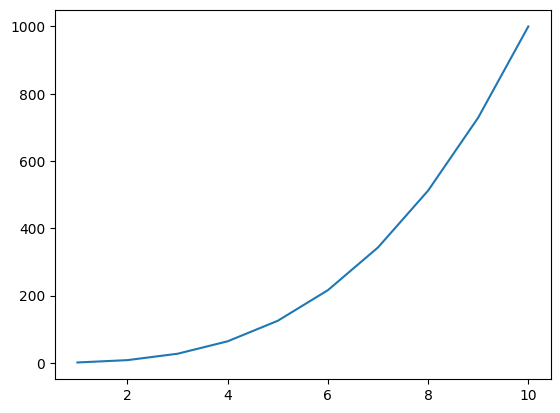

In [232]:
PlotPower(np.arange(1,11), 3)

# Question 16

In [234]:
boston = load_data('Boston')
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [244]:
boston['crim01']=(boston['crim'].median() < boston['crim']).astype(int)


In [246]:
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv,crim01
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806,0.500000
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104,0.500495
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000,0.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000,0.000000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000,0.500000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000,1.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000,1.000000


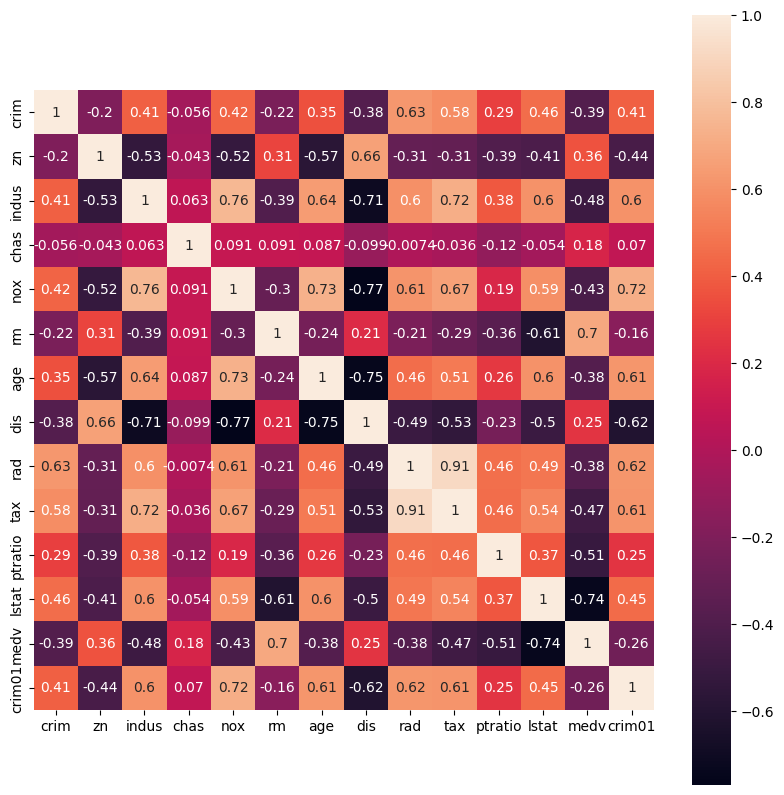

In [245]:
fig, ax = subplots(figsize=(10,10))
sns.heatmap(boston.corr(), square=True, annot=True)
plt.show()

the predictors which are significant seems to be tax, rad, dis, age, nox, indus,

In [250]:
def fit_and_error(x,y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
    models = [LR, LDA, QDA, GaussianNB]
    for m in models:
        model = m().fit(x_train, y_train)
        predicted = model.predict(x_test)
        print(confusion_table(predicted, y_test))
        print(f'The accuracy of {m.__name__} is {(np.mean(predicted == y_test))*100:.3f}\n')
        
    

In [252]:
x = boston[['tax', 'rad', 'dis', 'age', 'nox', 'indus']]
y = boston['crim01']
fit_and_error(x, y);

Truth       0   1
Predicted        
0          64  16
1          11  61
The accuracy of LogisticRegression is 82.237

Truth       0   1
Predicted        
0          71  23
1           4  54
The accuracy of LinearDiscriminantAnalysis is 82.237

Truth       0   1
Predicted        
0          71  15
1           4  62
The accuracy of QuadraticDiscriminantAnalysis is 87.500

Truth       0   1
Predicted        
0          68  22
1           7  55
The accuracy of GaussianNB is 80.921



f:\Online Courses\ISLP\islp_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


now lets do knn classification, at first start by standardizing the dataset

In [269]:
scaler = StandardScaler()
x_std = scaler.fit_transform(x)
x_std = pd.DataFrame(x_std, columns=x.columns)

In [268]:
x_train_std, x_test_std, y_train_std, y_test_std = train_test_split(x_std, y, test_size=0.4, random_state=1)

In [270]:
error_rate = {}
for k in range (1, 200):
    knn = KNN(n_neighbors=k)
    model = knn.fit(x_train_std, y_train_std)
    prediction = model.predict(x_test_std)
    c = confusion_table(prediction, y_test_std)
    error = ((c.iloc[0,1]+c.iloc[1,0])/(c.sum().sum()))*100
    error_rate[k] = error
    

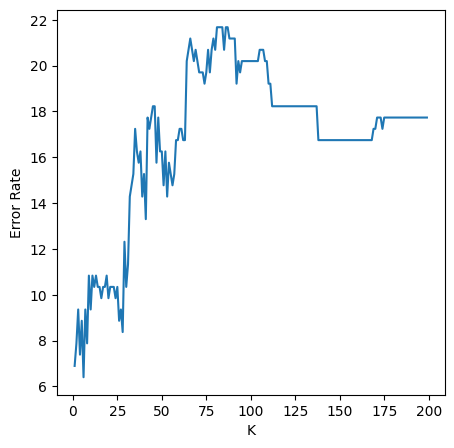

In [271]:
fig, ax = subplots(figsize=(5,5))
ax.plot(error_rate.keys(), error_rate.values())
ax.set_xlabel('K')
ax.set_ylabel('Error Rate')
plt.show()

In [275]:
min(error_rate.items(), key=lambda x: x[1])

(6, np.float64(6.403940886699508))

from this we can conclude that, we get lowest error for k value of 6 with an error rate of just 6.4%